In [11]:
from gen_trace import *
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta
import numpy as np
from collections import defaultdict

In [12]:
REFERENCE_TIME = datetime(2024, 1, 1, 0, 0, 0)

In [14]:
color_list = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]


def plot_arrivals(per_stream_arrivals: dict[str, list[Query]]):
    num_streams = len(per_stream_arrivals)

    fig, axs = plt.subplots(
        num_streams + 1,
        1,
        figsize=(20, (num_streams + 1) * 2),
        sharex=True,
        sharey=True,
    )

    stream_colors = {
        stream: color_list[i]
        for i, stream in enumerate(per_stream_arrivals.keys())
    }

    # Find the minimum and maximum arrival times across all streams.
    min_arrival_time = min(
        min(arrival.arrival_time for arrival in arrivals)
        for arrivals in per_stream_arrivals.values()
    )
    max_arrival_time = max(
        max(arrival.arrival_time for arrival in arrivals)
        for arrivals in per_stream_arrivals.values()
    )

    min_minute = min_arrival_time.replace(second=0, microsecond=0)
    max_minute = max_arrival_time.replace(second=0, microsecond=0)
    print(f"Minimum arrival time: {min_arrival_time} - min minute: {min_minute}")
    print(f"Maximum arrival time: {max_arrival_time} - max minute: {max_minute}")
    minutes_list = [
        min_minute + timedelta(minutes=m)
        for m in range(int((max_minute - min_minute).total_seconds() // 60) + 1)
    ]
    print(f"Plotting arrivals from {min_arrival_time} to {max_arrival_time} ({len(minutes_list)} minutes)")

    # Process each stream.
    for i, (stream, arrivals) in enumerate(per_stream_arrivals.items()):

        ax = axs[i]
        # First create empty per-minute counts for the entire range of minutes
        # from min_arrival_time to max_arrival_time.
        counts = defaultdict(int)
        for arrival in arrivals:
            minute = arrival.arrival_time.replace(second=0, microsecond=0)
            counts[minute] += 1

        # Now plot as a filled line chart.
        counts_list = [counts[minute] for minute in minutes_list]
        ax.fill_between(
            minutes_list,
            counts_list,
            step="post",
            color=stream_colors[stream],
            alpha=0.5,
            label=stream,
        )
        ax.set_ylabel("Arrivals per Minute")
        ax.set_title(f"Arrivals per Minute for Stream: {stream}")

    # Also plot the combined arrivals across all streams in the last subplot.
    combined_counts = defaultdict(int)
    for _, arrivals in per_stream_arrivals.items():
        for arrival in arrivals:
            minute = arrival.arrival_time.replace(second=0, microsecond=0)
            combined_counts[minute] += 1

    combined_counts_list = [combined_counts[minute] for minute in minutes_list]
    axs[-1].fill_between(
        minutes_list,
        combined_counts_list,
        step="post",
        color="black",
        alpha=0.5,
        label="Combined",
    )
    axs[-1].set_ylabel("Arrivals per Minute")
    axs[-1].set_title("Combined Arrivals per Minute")
    axs[-1].set_xlabel("Time")

    plt.tight_layout()
    plt.show()

/home/markakis/chunkbench/experiments/14_forecasting/gen_trace.py:140: RuntimeWarning: divide by zero encountered in scalar divide
  arrival_time = minute_start + timedelta(


Minimum arrival time: 2024-01-01 00:00:00 - min minute: 2024-01-01 00:00:00
Maximum arrival time: 2024-01-28 23:59:53.618104 - max minute: 2024-01-28 23:59:00
Plotting arrivals from 2024-01-01 00:00:00 to 2024-01-28 23:59:53.618104 (40320 minutes)


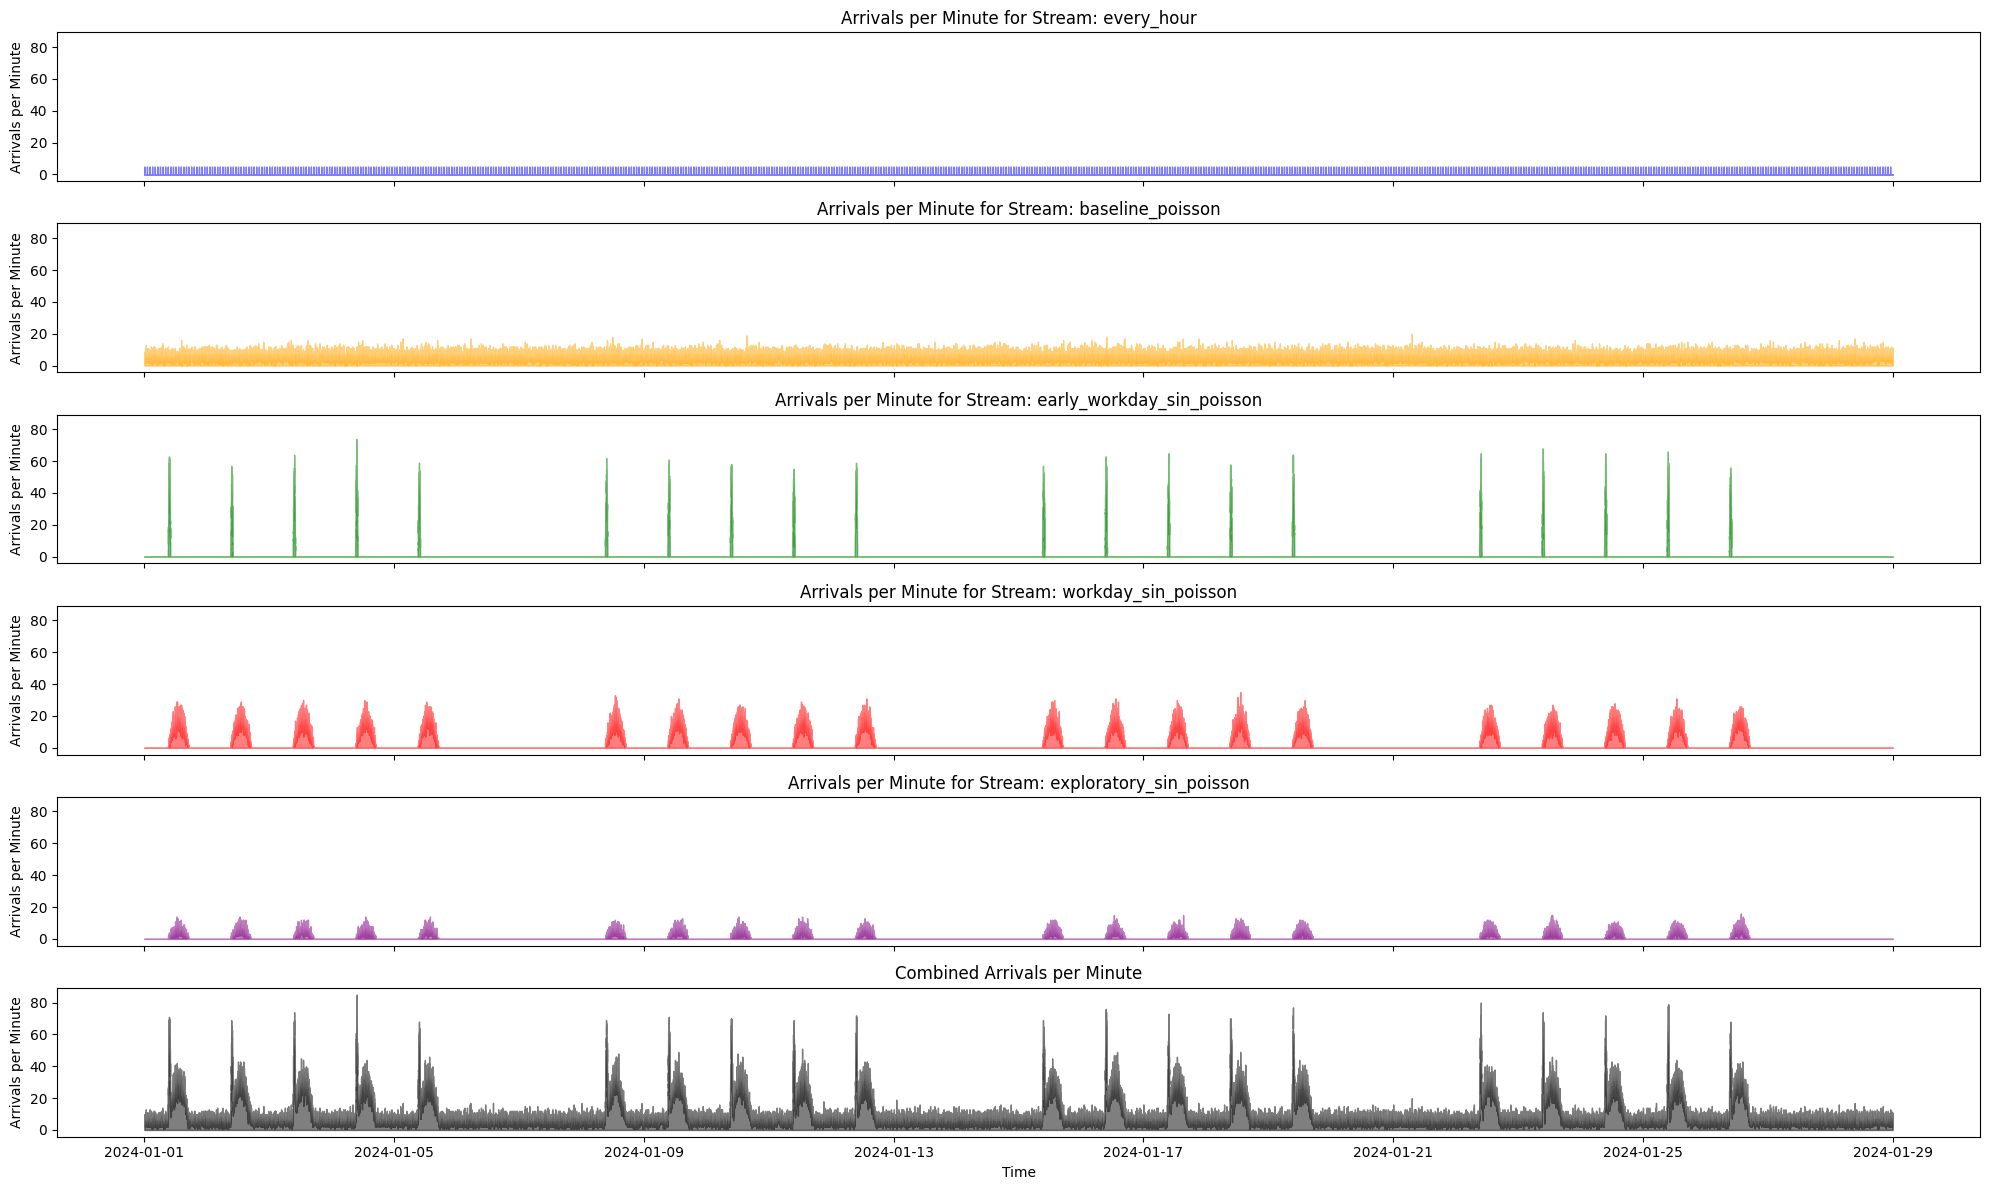

In [15]:
template_list_1 = [f"{i}" for i in range(1,3)]
process_1 = NoisyPeriodicProcess(
    period_s=3600, window_width_s=60, name='every_hour', queries_per_window=5, template_list=template_list_1
)
arrivals_1 = process_1.generate(
    start_time=REFERENCE_TIME,
    end_time=REFERENCE_TIME + timedelta(weeks=4)
)

template_list_234 = [f"{i}" for i in range(3, 10)]
process_2 = PoissonProcess(rate=0.1, name='baseline_poisson', template_list=template_list_234)
arrivals_2 = process_2.generate(
    start_time=REFERENCE_TIME,
    end_time=REFERENCE_TIME + timedelta(weeks=4)
)

process_3 = SinusoidalPoissonProcess(max_rate=0.8, name='early_workday_sin_poisson', template_list=template_list_234)
arrivals_3_nested = [process_3.generate(
    start_time=REFERENCE_TIME + timedelta(days=day_idx, hours=9),  # Start at 9 AM
    end_time=REFERENCE_TIME + timedelta(days=day_idx, hours=10),    # End at 10 AM
    seed = 42 + day_idx
) for day_idx in range(28)]
arrivals_3 = [arrival for j, daily_arrivals in enumerate(arrivals_3_nested) for arrival in daily_arrivals if j % 7 < 5 ]

process_4 = SinusoidalPoissonProcess(max_rate=0.3, name='workday_sin_poisson', template_list=template_list_234)
arrivals_4_nested = [process_4.generate(
    start_time=REFERENCE_TIME + timedelta(days=day_idx, hours=9),  # Start at 9 AM
    end_time=REFERENCE_TIME + timedelta(days=day_idx, hours=17),    # End at 5 PM
    seed = 42 + day_idx
) for day_idx in range(28)]
arrivals_4 = [arrival for j, daily_arrivals in enumerate(arrivals_4_nested) for arrival in daily_arrivals if j % 7 < 5 ]

template_list_5 = [f"{i}" for i in range(10, 1000)]
process_5 = SinusoidalPoissonProcess(max_rate=0.1, name='exploratory_sin_poisson', template_list=template_list_5)
arrivals_5_nested = [process_5.generate(
    start_time=REFERENCE_TIME + timedelta(days=day_idx, hours=9),  # Start at 9 AM
    end_time=REFERENCE_TIME + timedelta(days=day_idx, hours=17),    # End at 5 PM
    seed = 42 + day_idx
) for day_idx in range(28)]
arrivals_5 = [arrival for j, daily_arrivals in enumerate(arrivals_5_nested) for arrival in daily_arrivals if j % 7 < 5 ]

plot_arrivals(
    {
        process_1.name: arrivals_1,
        process_2.name: arrivals_2,
        process_3.name: arrivals_3,
        process_4.name: arrivals_4,
        process_5.name: arrivals_5,
    }
)

In [16]:
comnbined_arrivals = arrivals_1 + arrivals_2 + arrivals_3 + arrivals_4 + arrivals_5
comnbined_arrivals.sort(key=lambda x: x.arrival_time)


In [17]:
import os
import autoslo.utils.paths as pu
import pandas as pd

In [19]:
# Write it out to a file.
comnbined_arrivals[0]

trace_entries  = []
for i, arrival in enumerate(comnbined_arrivals):
    trace_entries.append(
       {
           "workload_id": "combined_arrivals",
           'query_id': f"{i}",
           "rel_start_time_s": arrival.start_time_s,
           "query_template": arrival.tpcds_temp_and_q_idx.split("_")[-1],  # Just use the prefix of the template as the template ID for simplicity.
           "query_num_within_template": 0,  # Not tracking this in the generator, so just set to 0 for all.
           "query_text": ""
       }
    )

trace_df = pd.DataFrame(trace_entries)
out_path = os.path.join(pu.get_data_path(), "test_workloads", "combined_arrivals.parquet")
trace_df.to_parquet(out_path, index=False)


In [20]:
from autoslo.forecasting.arrival_classifier import ArrivalClassifier
classifier = ArrivalClassifier(comnbined_arrivals)
template_windowness_results = classifier.classify_arrivals()

Analyzing 999 distinct templates

Classification  # Templates     % Templates     # Queries       % Queries

normal          7               0.70%           388335          90.65%

windowed        2               0.20%           3360            0.78%

ad-hoc          990             99.10%          36703           8.57%